In [131]:
import numpy as np
#import deepcave
from deepcave import Recorder, Objective
import io 
from PIL import Image
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [132]:
replacement_dict = {"atari_qbert": "atari", 'atari_double_dunk': "atari", 'atari_phoenix': "atari", 'atari_this_game': "atari", 
                    'box2d_lunar_lander': "box2d", 'cc_acrobot': "cc", 'cc_cartpole': "cc", 'cc_mountain_car': "cc", 
                    'minigrid_door_key': "minigrid", 'minigrid_empty_random': "minigrid", 'minigrid_four_rooms': "minigrid", 
                    'minigrid_unlock': "minigrid"}

In [133]:
def plotly_fig2array(fig):
    #convert Plotly fig to  an array
    fig_bytes = fig.to_image(format="png")
    buf = io.BytesIO(fig_bytes)
    img = Image.open(buf)
    return np.asarray(img)

In [134]:
def data_to_deepcave(data, save_path=None):
    configspace = CS.ConfigurationSpace(seed=0)
    alpha = CS.hyperparameters.UniformFloatHyperparameter(name="alpha", lower=0, upper=1)
    beta = CS.hyperparameters.Constant(name="beta", value=1)

    configspace.add_hyperparameters([alpha, beta])

    accuracy = Objective("accuracy", lower=0, upper=1, optimize="upper")
    time = Objective("time")
    save_path = save_path if save_path else "logs/DeepCAVE/minimal"

    with Recorder(configspace, objectives=[accuracy, time], save_path=save_path) as r:
        for config in configspace.sample_configuration(100):
            for budget in [20, 40, 60]:
                r.start(config, budget)

                # Your code goes here
                accuracy = np.random.uniform(low=0.0, high=1.0, size=None)

                r.end(costs=[accuracy, None])
    return save_path

In [135]:
def get_footprint():
    # Instantiate the run
    run = DeepCAVERun.from_path(Path("logs/DeepCAVE/minimal/run_2"))
    objective_id = run.get_objective_ids()[0]
    budget_id = run.get_budget_ids()[-1]

    # Instantiate the plugin
    plugin = PartialDependencies()
    inputs = plugin.generate_inputs(
        hyperparameter_name_1="alpha",
        hyperparameter_name_2="beta",
        objective_id=objective_id,
        budget_id=budget_id,
        show_confidence=False,
        show_ice=True,
    )
    # Note: Filter variables are not considered.
    outputs = plugin.generate_outputs(run, inputs)

    # Finally, you can load the figure. Here, the filter variables play a role.
    # Alternatively: Use the matplotlib output (`load_mpl_outputs`) if available.
    figure = plugin.load_outputs(run, inputs, outputs)  # plotly.go figure
    return plotly_fig2array(figure)

In [136]:
def normalize_env_scores(data):
    groups = data.groupby("Environment")["Score"]
    data["Score"] = (data["Score"] - groups.transform('min')) / (groups.transform('max') - groups.transform('min'))
    return data

In [137]:
def get_boxenplot(data, domain=False, domain_single=None):
    if domain:
        data["Environment"] = data["Environment"].replace(replacement_dict)
    if domain_single in ["atari", "cc", "box2d", "minigrid"]:
        subdomains = [k for k in replacement_dict.keys() if replacement_dict[k] == domain_single]
        data = data[data["Environment"].isin(subdomains)]
    fig = sns.boxenplot(data, x="Environment", y="Score")
    plt.xticks(rotation=70)
    plt.tight_layout()
    return fig

def get_kdeplot(data, domain=False, domain_single=None):
    if domain:
        data["Environment"] = data["Environment"].replace(replacement_dict)
    if domain_single in ["atari", "cc", "box2d", "minigrid"]:
        subdomains = [k for k in replacement_dict.keys() if replacement_dict[k] == domain_single]
        data = data[data["Environment"].isin(subdomains)]
    return sns.kdeplot(data, x="Score", hue="Environment")

def get_pairplot(data, domain=False, domain_single=None):
    if domain:
        data["Environment"] = data["Environment"].replace(replacement_dict)
    if domain_single in ["atari", "cc", "box2d", "minigrid"]:
        subdomains = [k for k in replacement_dict.keys() if replacement_dict[k] == domain_single]
        data = data[data["Environment"].isin(subdomains)]
    return sns.pairplot(data, hue="Environment", kind="kde")

In [138]:
def load_data(algorithm):
    source_file = f"data/{algorithm}/performances.csv"
    meta_file = f"data/{algorithm}/metadata.json"
    with open(meta_file) as f:
        metadata = json.load(f)
    return pd.read_csv(source_file), metadata

In [139]:
algorithm = "dqn"
performance_data, metadata = load_data(algorithm)
performance_data = normalize_env_scores(performance_data)

<Axes: xlabel='Environment', ylabel='Score'>

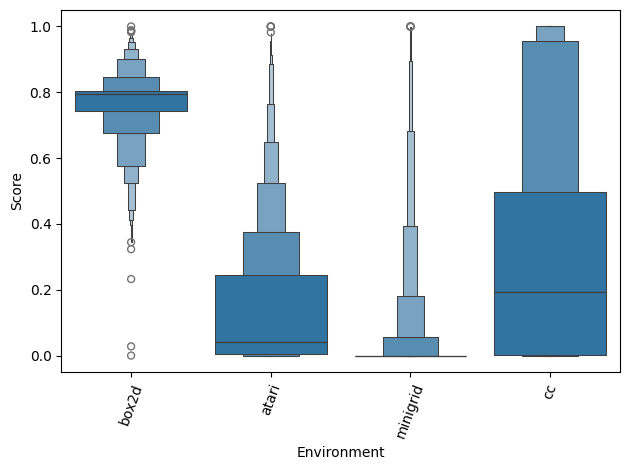

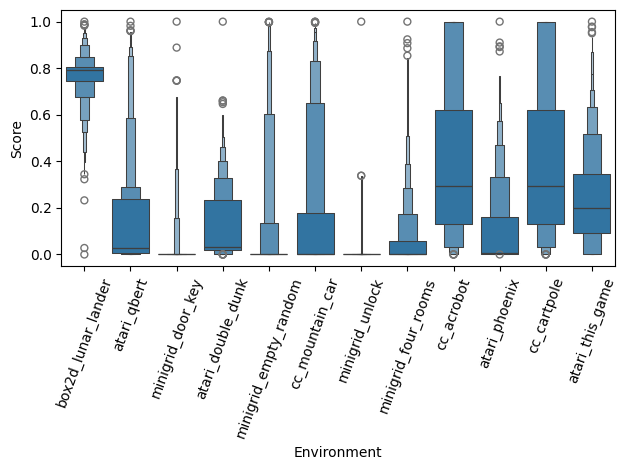

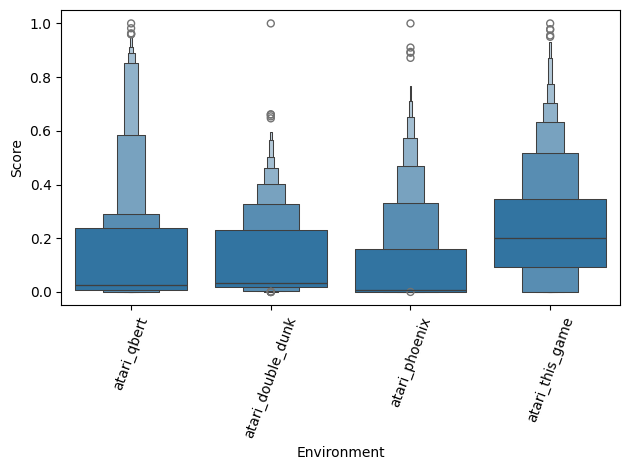

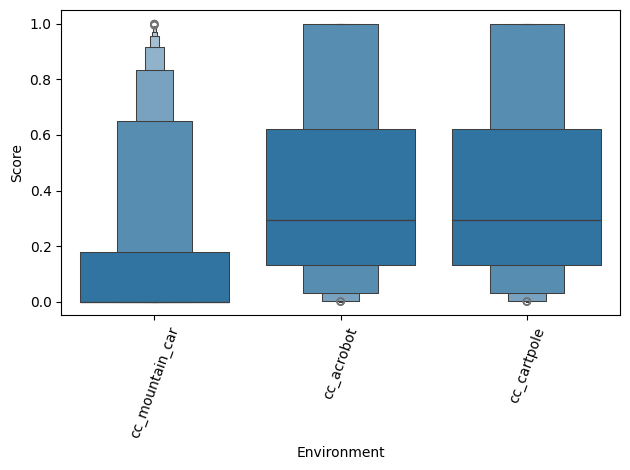

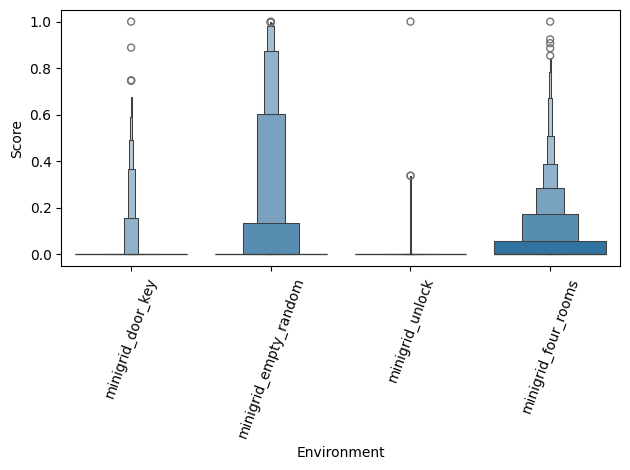

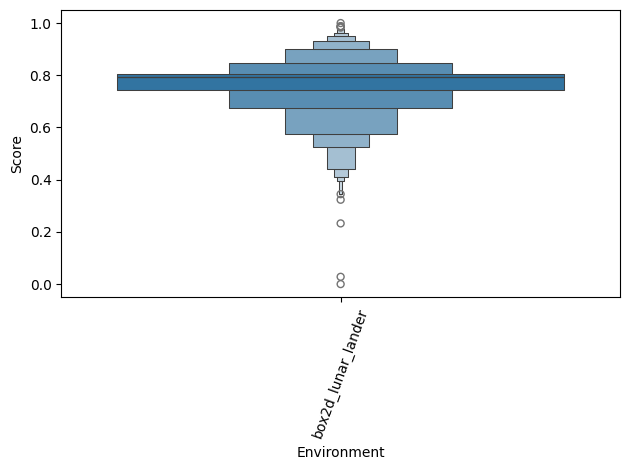

In [140]:
get_boxenplot(performance_data.copy(), True)
plt.figure()
get_boxenplot(performance_data.copy())
plt.figure()
get_boxenplot(performance_data.copy(), domain_single="atari")
plt.figure()
get_boxenplot(performance_data.copy(), domain_single="cc")
plt.figure()
get_boxenplot(performance_data.copy(), domain_single="minigrid")
plt.figure()
get_boxenplot(performance_data.copy(), domain_single="box2d")


<Axes: xlabel='Score', ylabel='Density'>

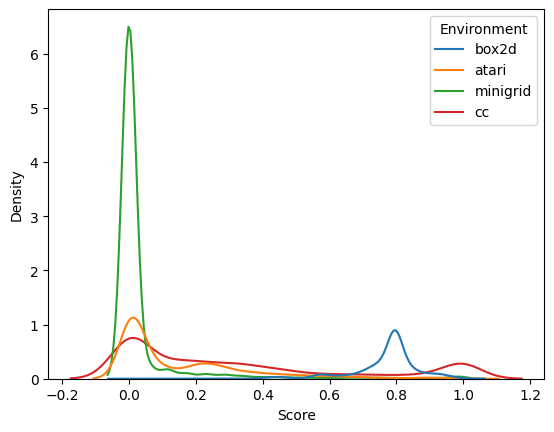

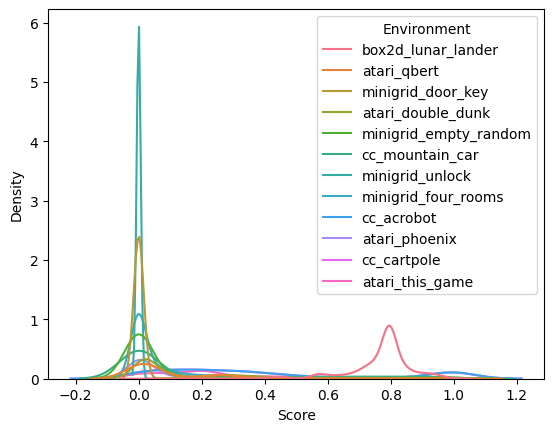

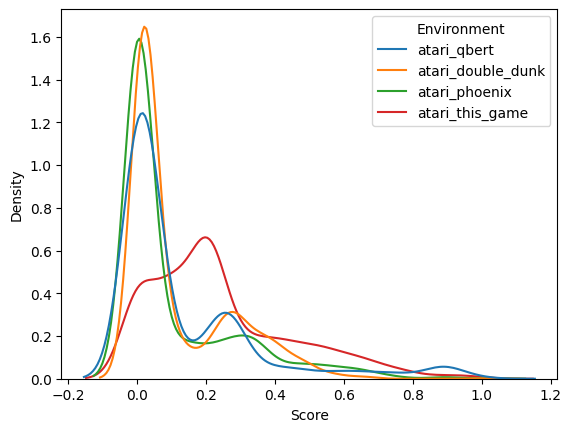

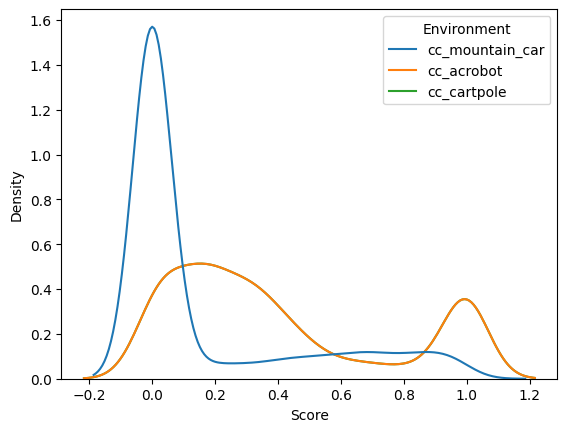

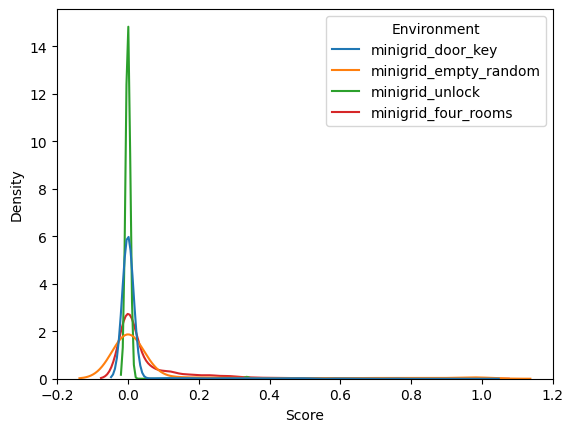

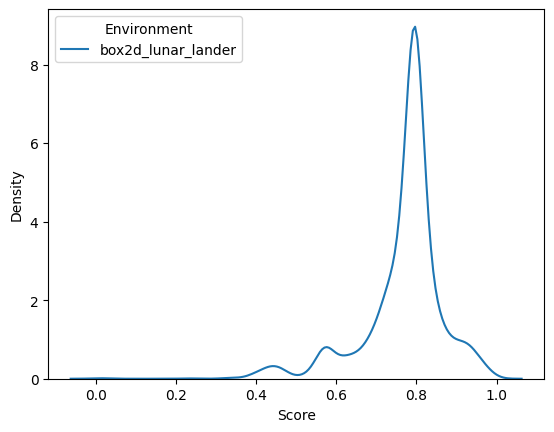

In [141]:
get_kdeplot(performance_data.copy(), True)
plt.figure()
get_kdeplot(performance_data.copy())
plt.figure()
get_kdeplot(performance_data.copy(), domain_single="atari")
plt.figure()
get_kdeplot(performance_data.copy(), domain_single="cc")
plt.figure()
get_kdeplot(performance_data.copy(), domain_single="minigrid")
plt.figure()
get_kdeplot(performance_data.copy(), domain_single="box2d")

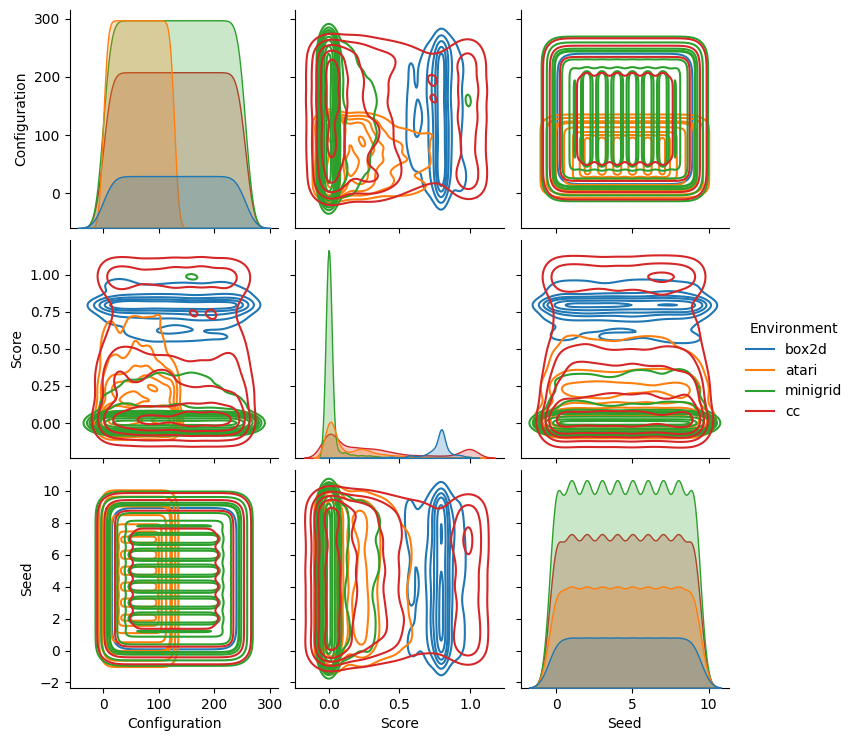

<Figure size 640x480 with 0 Axes>

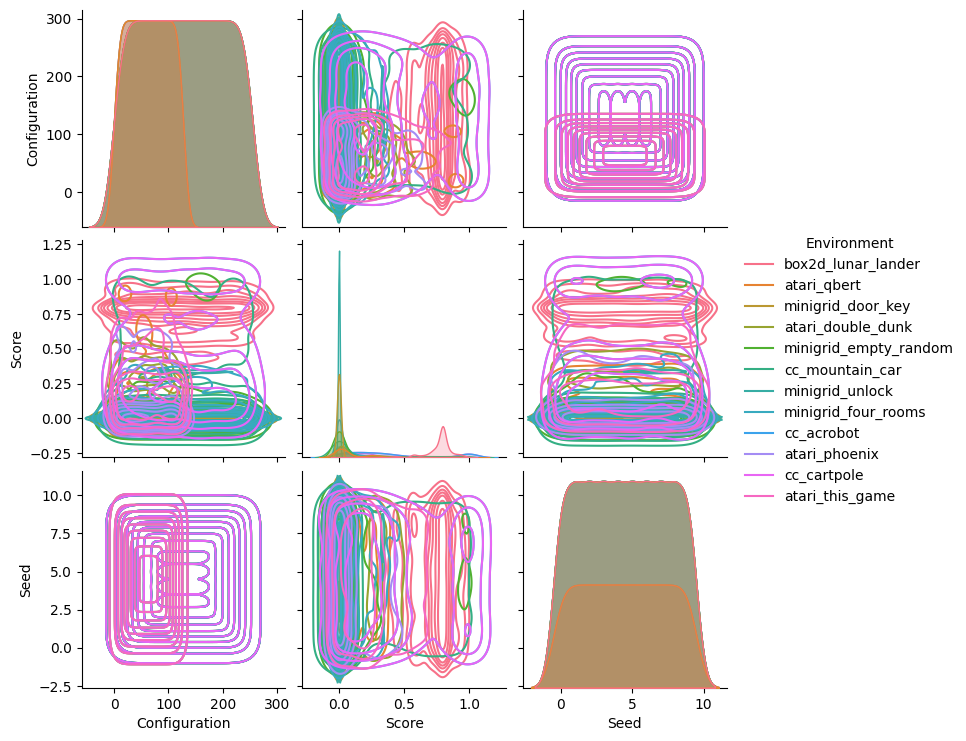

<Figure size 640x480 with 0 Axes>

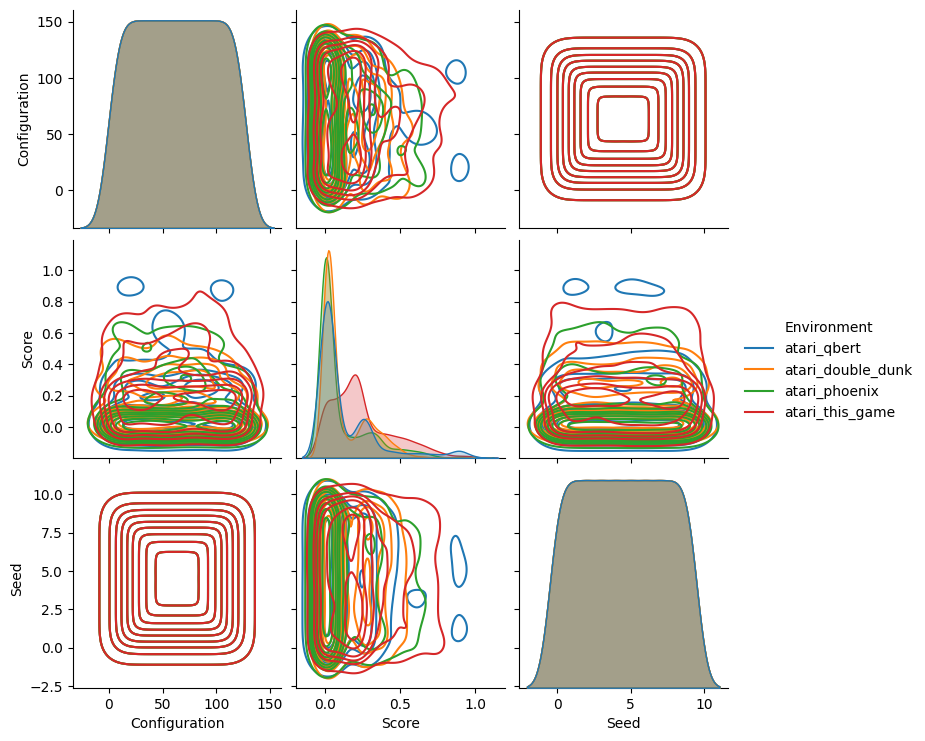

<Figure size 640x480 with 0 Axes>

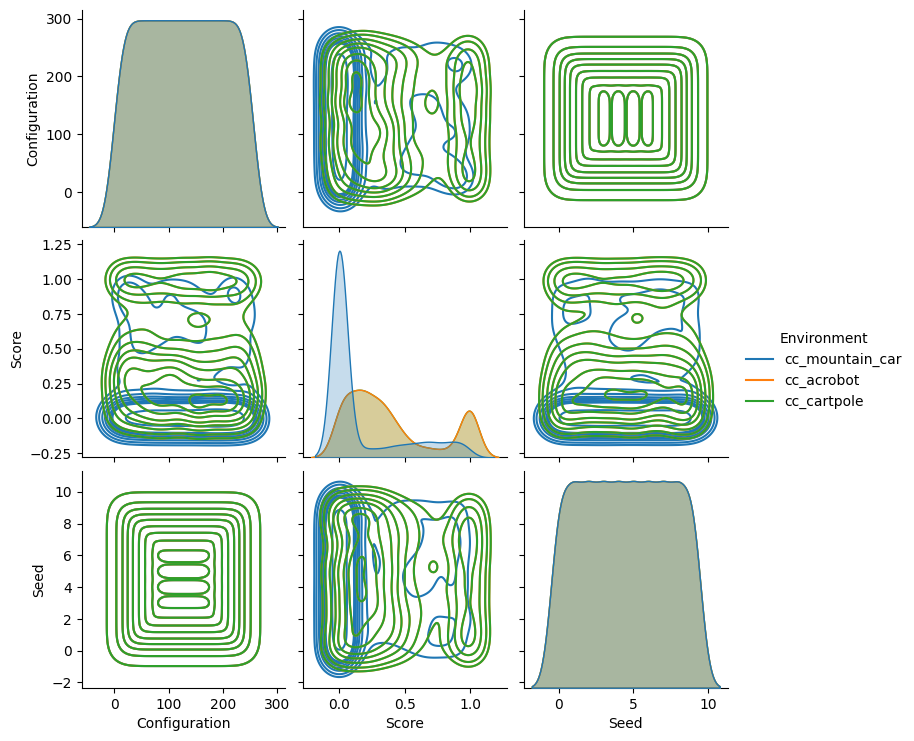

<Figure size 640x480 with 0 Axes>

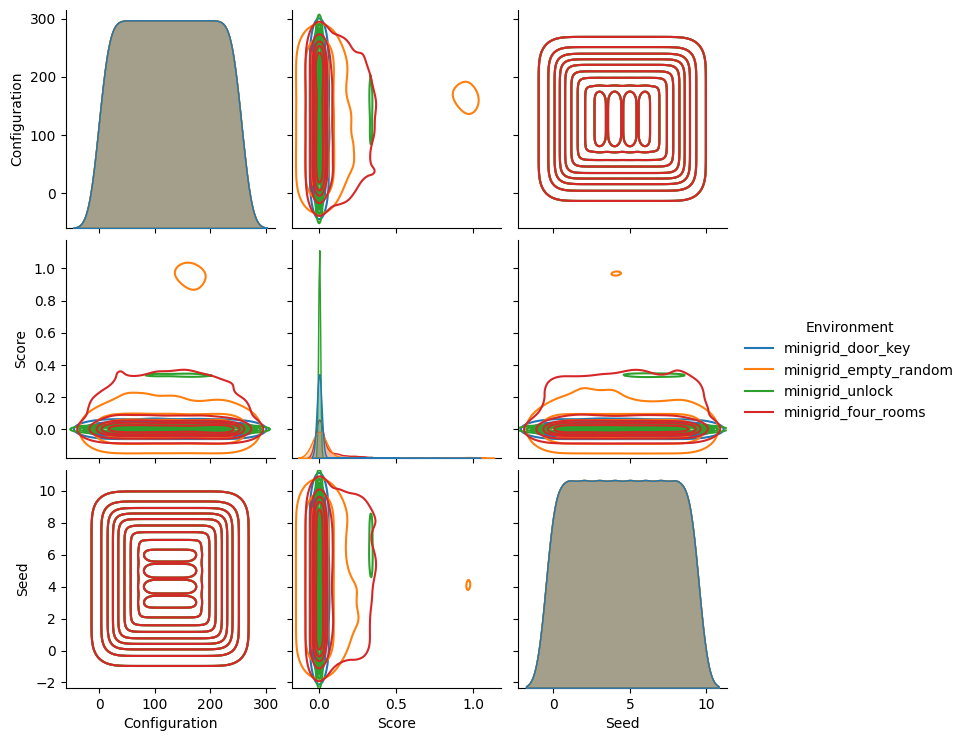

<Figure size 640x480 with 0 Axes>

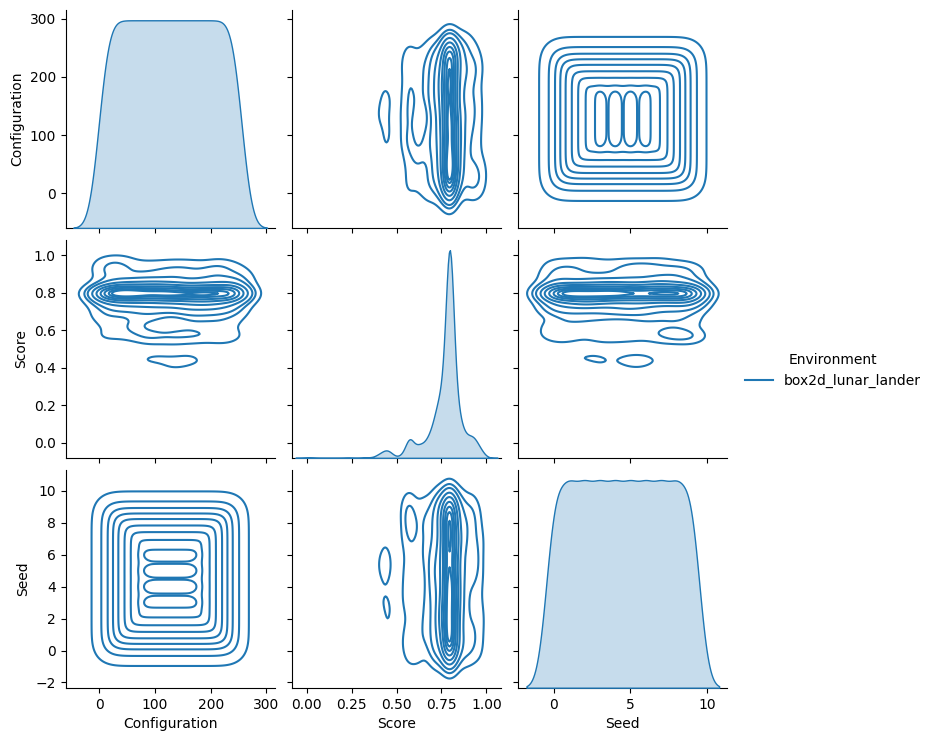

In [142]:
get_pairplot(performance_data.copy(), True)
plt.figure()
get_pairplot(performance_data.copy())
plt.figure()
get_pairplot(performance_data.copy(), domain_single="atari")
plt.figure()
get_pairplot(performance_data.copy(), domain_single="cc")
plt.figure()
get_pairplot(performance_data.copy(), domain_single="minigrid")
plt.figure()
get_pairplot(performance_data.copy(), domain_single="box2d")